# <u>**Laboratório 2 – Extração de Características Features**</u>

**Integrantes**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**

03/06/2026

**Data de Publicação do Relatório**

10/06/2026

## <u>Introdução</u>

A área de Visão Computacional frequentemente se depara com o desafio de analisar, comparar e extrair informações úteis de diferentes cenários. De maneira análoga à montagem de um quebra-cabeça, em que peças lisas e uniformes são difíceis de conectar e quinas singulares são facilmente identificáveis, os algoritmos dependem da localização de "pontos de interesse" (ou features) para mapear e processar dados visuais. O presente relatório tem como objetivo explorar a teoria fundamental por trás da detecção e descrição dessas características, conceitos que servem como pilar para aplicações computacionais complexas, e aplicar esse conhecimento em experimentos laboratoriais práticos.  

O princípio básico da detecção de características estabelece que os cantos (corners) são os pontos de referência mais confiáveis em uma imagem. Diferente de superfícies planas ou de bordas retas, os cantos apresentam alta variação de intensidade de pixel em todas as direções de deslocamento, tornando-os únicos e rastreáveis. Para traduzir essa intuição geométrica em linguagem computacional, estuda-se o Detector de Cantos de Harris, que introduziu o uso de janelas deslizantes e o cálculo de autovalores para pontuar matematicamente a presença de vértices. Como uma evolução, aborda-se também o Detector de Shi-Tomasi, que simplificou a função de pontuação de Harris para focar exclusivamente na menor variação de intensidade, resultando em um algoritmo mais eficiente para o rastreamento de características.  

Embora métodos baseados em cantos sejam robustos e invariantes à rotação, eles falham significativamente diante de variações de escala, visto que um vértice pode perder suas propriedades angulares ao sofrer ampliação. Para contornar essa limitação crítica, analisa-se o funcionamento do algoritmo SIFT (Scale-Invariant Feature Transform). O SIFT soluciona o problema da escala ao buscar pontos de interesse através de múltiplas resoluções e criar um "descritor" robusto.  

Compreender o funcionamento de tais métodos fornece a base para a segunda e principal etapa deste laboratório. Para além da fundamentação teórica, este relatório documenta testes práticos e executáveis de detecção de features e geometria. Especificamente, serão detalhados os procedimentos para implementar o algoritmo SIFT no reconhecimento e correspondência de características (Feature Matching) aliada à homografia para encontrar objetos em posições distintas.

## Fundamentação teórica

O algoritmo SIFT (Scale-Invariant Feature Transform) é um dos métodos mais consolidados na visão computacional para localizar e descrever pontos de interesse estáveis. Sua principal vantagem é a capacidade de extrair características que permanecem invariantes a diversas mudanças no ambiente da captura, como iluminação, escala, rotação e ponto de vista (viewpoint) (BURGER, 2016). Essa robustez garante altas taxas de reconhecimento de objetos em diferentes bases de dados e desempenha um papel fundamental em aplicações de robótica e visão de máquina, permitindo que características sejam confiavelmente correspondidas em imagens diferentes (DORST, 2011).

Enquanto o SIFT se destaca por sua invariância geométrica, o Detector de Harris é um método clássico amplamente utilizado para a localização de cantos (corners). No entanto, o algoritmo de Harris apresenta limitações importantes: diferentemente do SIFT, ele não é invariante a mudanças no tamanho (escala) da imagem. Comparações diretas na literatura demonstram que o SIFT supera o Harris em tarefas de correspondência sob mudanças de escala justamente por essa característica geométrica (GODBIN, 2025). Devido a esses trade-offs de eficiência computacional e precisão, avaliações extensas são frequentemente realizadas. Estudos recentes compararam o desempenho do SIFT contra o Harris e o filtro LoG (Laplacian of Gaussian) (ABDULLAH et al., 2026), e avaliações massivas utilizando bases com mais de 1,5 milhão de imagens contrastaram o SIFT com métodos tradicionais como FAST e AKAZE (IŞIK, 2024).

Na prática, a extração de características estáveis viabiliza soluções complexas de correspondência (matching) e registro de imagens. Essas técnicas são aplicadas para alinhar imagens com sobreposições, lidando de forma eficaz com oclusões, fundos complexos (clutter) e variações bruscas de iluminação. Graças a essas propriedades, métodos baseados no SIFT são essenciais para o reconhecimento de objetos, rastreamento em vídeo, registro multissensor e a criação de mosaicos panorâmicos (KHER; THAKAR, 2014).

Por fim, a robustez da lógica de pontos do SIFT levou à sua expansão para domínios além da fotografia óptica tradicional. Em aplicações que sofrem com ruídos muito específicos, o algoritmo foi adaptado para garantir o mesmo nível de precisão. Um exemplo notório na área de sensoriamento remoto é o SAR-SIFT, uma variação desenvolvida especificamente para o registro de imagens de radar de abertura sintética (SAR), capaz de lidar adequadamente com o ruído do tipo speckle inerente a esse formato (DELLINGER et al., 2014).

### Fundamentação matemática
A robustez do algoritmo SIFT (descrita anteriormente) é alcançada através de uma sequência de operações matemáticas rigorosas, divididas em quatro etapas principais que transformam os pixels da imagem em vetores descritores independentes da escala e rotação:
1. **Detecção de Extremos no Espaço de Escala (Diferença de Gaussianas - DoG):**
Para garantir que as características sejam encontradas independentemente da distância ou zoom da câmera, o SIFT procura pontos de interesse em diferentes "escalas". Isso é feito aplicando o filtro Gaussiano à imagem original em vários níveis de desfoque (blur). A imagem em uma escala específica é definida por:$$L(x,y,\sigma) = G(x,y,\sigma) * I(x,y)$$Onde $L$ é a imagem suavizada, $I$ é a imagem original, e $G$ é o filtro Gaussiano com variância $\sigma^2$.Em seguida, em vez de usar uma função mais custosa (como o Laplaciano do Gaussiano - LoG), o SIFT aproxima isso subtraindo imagens adjacentes nesse espaço de escala, gerando a Diferença de Gaussianas (DoG):$$D(x,y,\sigma) = L(x,y,k\sigma) - L(x,y,\sigma)$$Os pontos de interesse (keypoints) são identificados como os máximos e mínimos locais dessa função DoG ao comparar um pixel com seus 26 vizinhos (8 na mesma escala, 9 na escala acima e 9 na escala abaixo).
2. **Localização Precisa dos Keypoints e Filtragem:**
Os pontos encontrados no passo anterior são apenas coordenadas em pixels inteiros. Para obter precisão sub-pixel, o SIFT utiliza a Expansão de Taylor da função de escala para interpolar a localização exata do extremo.Além disso, pontos de baixo contraste ou localizados em bordas (que são instáveis) precisam ser descartados. Para eliminar respostas de bordas, o SIFT utiliza a Matriz Hessiana (matriz de derivadas de segunda ordem) calculada no ponto. Se a razão entre a curvatura principal maior e a menor (obtidas pelos autovalores da matriz) for maior que um limite predefinido, o ponto é rejeitado como sendo uma borda e não um "canto" ou ponto isolado de interesse.
3. **Atribuição de Orientação:** Para garantir a invariância à rotação, o algoritmo atribui uma orientação de referência a cada keypoint. Em torno do ponto (na escala em que foi detectado), a magnitude ($m$) e a direção ($\theta$) do gradiente são calculadas usando as diferenças das intensidades dos pixels adjacentes:$$m(x,y) = \sqrt{(L(x+1,y) - L(x-1,y))^2 + (L(x,y+1) - L(x,y-1))^2}$$$$\theta(x,y) = \arctan\left(\frac{L(x,y+1) - L(x,y-1)}{L(x+1,y) - L(x-1,y)}\right)$$Um histograma de orientações é formado, e o pico desse histograma dita a orientação principal daquele keypoint.
4. **Construção do Descritor Local:** A etapa final transforma as informações ao redor do ponto em um vetor matemático único (a "impressão digital" da feature). O SIFT pega uma região de 16x16 pixels ao redor do keypoint (já alinhada com a orientação principal calculada no passo 3 para anular efeitos de rotação).Essa região é dividida em blocos de 4x4. Para cada um desses 16 blocos, calcula-se um histograma de orientação de gradientes de 8 direções (bins).Isso resulta em um array de 16 (blocos) $\times$ 8 (direções) = 128 valores. Esse vetor de 128 dimensões é o descritor final do SIFT, que é então normalizado para reduzir os efeitos de mudanças na iluminação.

## <u>Procedimentos Experimentais</u>

Nesta seção, detalharemos as etapas práticas desenvolvidas para a detecção e correspondência de características (feature matching) utilizando a linguagem Python e a biblioteca OpenCV. O experimento foi conduzido em duas fases de implementação. Inicialmente, construímos um script para processar imagens estáticas pré-capturadas de um mesmo objeto em ângulos distintos, aplicando o algoritmo SIFT associado ao cálculo de homografia para localizar os pontos de interesse e traçar as correspondências de forma robusta, esse script fi fortemente baseado no tutorial disponível no seguinte site: https://docs.opencv.org/4.13.0/d1/de0/tutorial_py_feature_homography.html. Na segunda fase, descrevemos o processo de adaptação deste código base para operar em tempo real. Essa modificação permitiu capturar simultaneamente o sinal de duas webcams, aplicando a mesma lógica de extração e correspondência do SIFT de forma contínua, quadro a quadro, e projetando os resultados visualmente em uma janela de vídeo durante a execução.

## SIFT

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

MIN_MATCH_COUNT = 10

img1 = cv.imread('objeto.png', cv.IMREAD_GRAYSCALE) # queryImage
img2 = cv.imread('objeto_2.png', cv.IMREAD_GRAYSCALE) # trainImage

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 10)
search_params = dict(checks = 50)

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1,des2,k=2)

# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.95*n.distance:
        good.append(m)

In [3]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()

    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv.perspectiveTransform(pts,M)

    img2 = cv.polylines(img2,[np.int32(dst)],True,255,3, cv.LINE_AA)

else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None

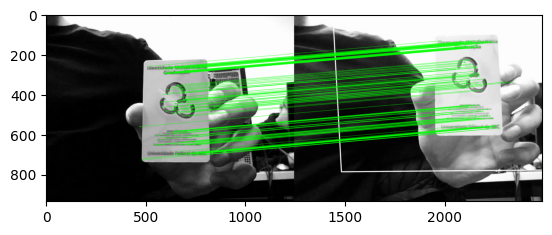

(<matplotlib.image.AxesImage at 0x7a0925fd3b60>, None)

In [4]:
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

plt.imshow(img3, 'gray'),plt.show()

In [ ]:
import numpy as np
import cv2 as cv

MIN_MATCH_COUNT = 10

# Inicia a captura de vídeo das duas webcams
# Dependendo do seu sistema, os índices podem ser 0 e 1, 1 e 2, etc.
cap1 = cv.VideoCapture(0)
cap2 = cv.VideoCapture(1)

# Inicia o detector SIFT
sift = cv.SIFT_create()

# Configurações do FLANN
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv.FlannBasedMatcher(index_params, search_params)

print("Pressione a tecla 'q' para sair.")

try:
    while True:
        # Captura os frames atuais de cada webcam
        ret1, frame1 = cap1.read()
        ret2, frame2 = cap2.read()

        # Verifica se os frames foram capturados corretamente
        if not ret1 or not ret2:
            print("Falha ao capturar imagens das webcams. Verifique as conexões ou os índices (0, 1).")
            break

        # SIFT funciona melhor e mais rápido em escala de cinza
        img1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
        img2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

        # Encontra os keypoints e descritores com SIFT
        kp1, des1 = sift.detectAndCompute(img1, None)
        kp2, des2 = sift.detectAndCompute(img2, None)

        # Verifica se os descritores foram encontrados (evita crash se a câmera focar em uma parede lisa, por exemplo)
        if des1 is not None and des2 is not None and len(des1) > 2 and len(des2) > 2:
            matches = flann.knnMatch(des1, des2, k=2)

            # Armazena os bons matches através do teste de razão de Lowe
            good = []
            for match in matches:
                # Segurança: garante que k=2 retornou dois itens antes de comparar
                if len(match) == 2:
                    m, n = match
                    if m.distance < 0.65 * n.distance:
                        good.append(m)

            matchesMask = None

            if len(good) > MIN_MATCH_COUNT:
                src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
                dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

                # Calcula a Homografia
                M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

                # Só tenta desenhar o polígono se a matriz de homografia (M) for válida
                if M is not None:
                    matchesMask = mask.ravel().tolist()
                    h, w = img1.shape
                    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
                    dst = cv.perspectiveTransform(pts, M)

                    # Desenha o polígono no frame colorido (frame2) para melhor visualização
                    frame2 = cv.polylines(frame2, [np.int32(dst)], True, (255, 0, 0), 3, cv.LINE_AA)

            # Configura os parâmetros de desenho
            draw_params = dict(matchColor = (0,255,0), # Cor dos matches em verde
                               singlePointColor = None,
                               matchesMask = matchesMask, # Desenha apenas os inliers se houver Homografia
                               flags = 2)

            # Desenha as linhas ligando as imagens (usando os frames coloridos)
            img_result = cv.drawMatches(frame1, kp1, frame2, kp2, good, None, **draw_params)

            # Exibe o resultado final
            cv.imshow('SIFT - Comparacao de Webcams em Tempo Real', img_result)

        else:
            # Se não encontrou descritores suficientes, exibe as imagens lado a lado sem os traços
            # Nota: as resoluções das duas câmeras precisam ter a mesma altura para o hstack funcionar
            try:
                img_result = np.hstack((frame1, frame2))
                cv.imshow('SIFT - Comparacao de Webcams em Tempo Real', img_result)
            except ValueError:
                cv.imshow('Webcam 1', frame1)
                cv.imshow('Webcam 2', frame2)

        # Interrompe o loop se a tecla 'q' for pressionada
        if cv.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    print("Desconectando do hardware e limpando a memória...")

    # Esvazia a fila de imagens do kernel do Linux "agarrando" e descartando o que sobrou
    if cap1.isOpened():
        cap1.grab()
        cap1.release()

    if cap2.isOpened():
        cap2.grab()
        cap2.release()

    cv.destroyAllWindows()

![print_duas_webcams](screenshots/two_webcams_screenshot.png)

## <u>Análise e Discussão dos Estudos</u>



Na primeira etapa prática, utilizando duas imagens estáticas contendo o mesmo objeto em posições distintas, verificou-se que o SIFT foi capaz de detectar pontos de interesse relevantes e gerar descritores suficientemente discriminantes para estabelecer correspondências confiáveis entre as imagens. A utilização da homografia mostrou-se essencial para eliminar correspondências incorretas e estimar a localização do objeto na cena, evidenciando como técnicas matemáticas complementam os descritores locais para aumentar a robustez do sistema. Esses resultados estão alinhados com os objetivos propostos pelo laboratório, que incluem compreender a extração de características e aplicá-las na identificação de objetos em diferentes imagens.

Na segunda etapa, a adaptação do código para o uso simultâneo de duas webcams evidenciou o potencial dessas técnicas em aplicações de tempo real. A atualização contínua das imagens impôs desafios adicionais, como variações de iluminação, pequenas oscilações na posição dos objetos e ruídos provenientes dos dispositivos de captura. Mesmo nessas condições, o método apresentou desempenho satisfatório, demonstrando que a correspondência baseada em features pode ser utilizada em sistemas dinâmicos, desde que sejam adotadas estratégias adequadas de filtragem e validação das correspondências.

As aplicações dessa técnica são bastante abrangentes e incluem reconhecimento e rastreamento de objetos, realidade aumentada, navegação robótica, reconstrução tridimensional de ambientes, inspeção industrial e sistemas biométricos, como o reconhecimento facial (KHER; THAKAR, 2014). Em todos esses cenários, a capacidade de identificar padrões únicos e invariantes a mudanças de escala, rotação e pequenas alterações de perspectiva contribui para aumentar a robustez e a precisão dos sistemas desenvolvidos. Os estudos realizados demonstraram que a correspondência baseada em features é eficaz tanto em imagens estáticas quanto em aplicações com aquisição contínua de vídeo, evidenciando sua versatilidade em diferentes contextos.

Considerando essas possibilidades, as técnicas estudadas neste laboratório apresentam grande potencial para serem exploradas em projetos finais da disciplina. A compreensão dos princípios de detecção, descrição e correspondência de características fornece uma base sólida para o desenvolvimento de soluções voltadas à análise automática de imagens, permitindo que os conhecimentos adquiridos sejam aplicados na resolução de problemas reais e em aplicações cada vez mais presentes no cotidiano e na indústria.

Portanto, os resultados obtidos demonstram que os métodos de detecção e correspondência de características são ferramentas versáteis e robustas, capazes de atender tanto aplicações clássicas de reconhecimento de objetos quanto sistemas mais complexos, como soluções de autenticação biométrica e identificação automática de indivíduos.

## <u>Conclusões</u>


Neste laboratório foi possível compreender os conceitos fundamentais de detecção e descrição de características (features) em Visão Computacional, bem como sua importância para o reconhecimento e correspondência de objetos em imagens. O estudo teórico permitiu analisar diferentes métodos de detecção de pontos de interesse, como Harris, Shi-Tomasi e SIFT, destacando suas principais características, vantagens e aplicações.

Na parte prática, a implementação do algoritmo SIFT demonstrou sua eficiência na identificação de características invariantes a escala, rotação e pequenas alterações de perspectiva. A realização do processo de correspondência entre duas imagens estáticas permitiu validar a capacidade do método em localizar corretamente o mesmo objeto em diferentes posições, utilizando técnicas de matching e homografia para estimar sua localização.

Além disso, a adaptação do sistema para aquisição simultânea de imagens por duas webcams mostrou a viabilidade da aplicação em tempo real, possibilitando a identificação e correspondência contínua de características entre diferentes pontos de vista. Os resultados obtidos evidenciaram a robustez do SIFT em cenários práticos, mantendo correspondências válidas mesmo diante de variações na cena.

Por fim, a pesquisa sobre aplicações da detecção de features demonstrou sua ampla utilização em áreas como reconhecimento de objetos, navegação robótica, realidade aumentada, reconstrução 3D, sistemas de visão autônoma e reconhecimento facial. A possibilidade de aplicar os conceitos estudados em soluções de autenticação biométrica, monitoramento e segurança evidencia o papel central da extração de características no desenvolvimento de tecnologias modernas. Dessa forma, os conhecimentos adquiridos neste laboratório não apenas atenderam aos objetivos propostos, mas também forneceram uma base sólida para o desenvolvimento de projetos mais avançados em Visão Computacional e para sua aplicação no trabalho final da disciplina.

## Referências Bibliográficas
ABDULLAH, M. et al. A Comprehensive Guide to Local Feature Detection and Description: Harris, LoG, and SIFT in Image Processing. [S.l.: s.n.], 2026.   
BURGER, W.; BURGE, M. J. Scale-Invariant Feature Transform (SIFT). In: Digital Image Processing. Springer, 2016. DOI: 10.1007/978-1-4471-6684-9_25.   
DELLINGER, F. et al. SAR-SIFT: A SIFT-Like Algorithm for SAR Images. IEEE Transactions on Geoscience and Remote Sensing, 2014.   
DORST, Matthijs C. Distinctive Image Features from Scale-Invariant Keypoints Abstract. [S.l.: s.n.], 2011.   
GODBIN. Image matching SIFT vs Harris. [S.l.: s.n.], 2025.   
IŞIK, Murat. Comprehensive empirical evaluation of feature extractors in computer vision. [S.l.: s.n.], 2024.   
KHER, H.; THAKAR, V. Scale Invariant Feature Transform Based Image Matching and Registration. In: 2014 Fifth International Conference on Signal and Image Processing. IEEE, 2014. DOI: 10.1109/icsip.2014.12.
OpenCV. Feature Matching + Homography to find Objects. OpenCV, 2025. Disponível em: https://docs.opencv.org/4.13.0/d1/de0/tutorial_py_feature_homography.html. Acesso em: 08, junho de 2026.
LOWE, D. G. Distinctive Image Features from Scale-Invariant Keypoints. International Journal of Computer Vision, v. 60, n. 2, p. 91–110, 2004.
KORTLI, Y.; JRIDI, M.; AL FISHER, M.; AOUITI, C.; MAHDI, W. Face Recognition Systems: A Survey. Sensors, v. 20, n. 2, p. 342, 2020.